In [39]:
!cat data.txt

组A 20	30	20	10	10	20	10	20	20	10	20	10	30	20	10	10	20	10	10	10	30	20	10	30	20	10	10	20	10	10	20	10	20	30	20	10	20	10	10	30
组B 30	30	30	30	20	20	10	20	20	30	20	20	30	20	30	20	20	30	20	20	30	30	20	30	40	30	20	30	30	20	20	30	20	40	30	40	20	30	30	50
组A 20	30	20	10	10	20	10	20	20	10	20	10	30	20	10	10	20	10	10	10	30	20	10	30	20	10	10	20	10	10	20	10	20	30	20	10	20	10	10	30
组B 30	30	30	30	20	20	10	20	20	30	20	20	30	20	30	20	20	30	20	20	30	30	20	30	40	30	20	30	30	20	20	30	20	40	30	40	20	30	30	50
组A 50	50	30	20	30	30	40	40	40	20	30	30	60	30	30	30	50	30	20	30	70	30	30	50	40	20	30	30	30	20	40	30	50	60	30	40	50	30	20	70
组B 70	70	80	70	60	50	40	50	60	80	60	60	80	60	60	60	60	80	60	60	80	60	60	80	90	70	60	70	80	60	70	70	60	90	60	80	60	70	70	100

In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [40]:
df = pd.read_csv("/content/data.txt", sep='\s+', header=None, index_col=0)

<>:1: SyntaxWarning: invalid escape sequence '\s'
<>:1: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipython-input-882571010.py:1: SyntaxWarning: invalid escape sequence '\s'
  df = pd.read_csv("/content/data.txt", sep='\s+', header=None, index_col=0)


In [41]:
df.head()

,1,2,3,4,5,6,7,8,9,10,...,31,32,33,34,35,36,37,38,39,40
0,,,,,,,,,,,,,,,,,,,,,
组A,20,30,20,10,10,20,10,20,20,10,...,20,10,20,30,20,10,20,10,10,30
组B,30,30,30,30,20,20,10,20,20,30,...,20,30,20,40,30,40,20,30,30,50
组A,20,30,20,10,10,20,10,20,20,10,...,20,10,20,30,20,10,20,10,10,30
组B,30,30,30,30,20,20,10,20,20,30,...,20,30,20,40,30,40,20,30,30,50
组A,50,50,30,20,30,30,40,40,40,20,...,40,30,50,60,30,40,50,30,20,70


In [47]:
level_1_labels = ["group_1", "group_1", "group_2", "group_2", "group_3", "group_3"]

In [48]:
level_2_labels = df.index

In [49]:
new_index = pd.MultiIndex.from_arrays([level_1_labels, level_2_labels],
                                      names=["number", "group"])

In [50]:
new_index

MultiIndex([('group_1', '组A'),
            ('group_1', '组B'),
            ('group_2', '组A'),
            ('group_2', '组B'),
            ('group_3', '组A'),
            ('group_3', '组B')],
           names=['number', 'group'])

In [51]:
df.index = new_index

In [52]:
df

1   2   3   4   5   6   7   8   9   10  ...  31  32  33  34  \
number  group                                          ...                   
group_1 组A     20  30  20  10  10  20  10  20  20  10  ...  20  10  20  30   
        组B     30  30  30  30  20  20  10  20  20  30  ...  20  30  20  40   
group_2 组A     20  30  20  10  10  20  10  20  20  10  ...  20  10  20  30   
        组B     30  30  30  30  20  20  10  20  20  30  ...  20  30  20  40   
group_3 组A     50  50  30  20  30  30  40  40  40  20  ...  40  30  50  60   
        组B     70  70  80  70  60  50  40  50  60  80  ...  70  70  60  90   

               35  36  37  38  39   40  
number  group                           
group_1 组A     20  10  20  10  10   30  
        组B     30  40  20  30  30   50  
group_2 组A     20  10  20  10  10   30  
        组B     30  40  20  30  30   50  
group_3 组A     30  40  50  30  20   70  
        组B     60  80  60  70  70  100  

[6 rows x 40 columns]

AttributeError: 'numpy.ndarray' object has no attribute 'boxplot'

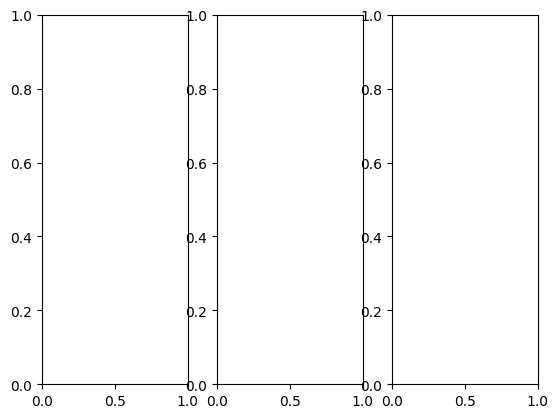

In [60]:
fig, axes = plt.subplots(1,3)
axes.boxplot(df,patch_artist=True)

In [53]:
df_long = df.stack().reset_index()
df_long.columns = ['实验组', '分组', '样本序号', '数值']

In [64]:
df_long.loc[df_long['分组'] == "组A"]['分组']

,分组
0,组A
1,组A
2,组A
3,组A
4,组A
...,...
195,组A
196,组A
197,组A
198,组A


/usr/local/lib/python3.12/dist-packages/seaborn/axisgrid.py:123: UserWarning: Glyph 23454 (\N{CJK UNIFIED IDEOGRAPH-5B9E}) missing from font(s) DejaVu Sans.
  self._figure.tight_layout(*args, **kwargs)
/usr/local/lib/python3.12/dist-packages/seaborn/axisgrid.py:123: UserWarning: Glyph 39564 (\N{CJK UNIFIED IDEOGRAPH-9A8C}) missing from font(s) DejaVu Sans.
  self._figure.tight_layout(*args, **kwargs)
/usr/local/lib/python3.12/dist-packages/seaborn/axisgrid.py:123: UserWarning: Glyph 32452 (\N{CJK UNIFIED IDEOGRAPH-7EC4}) missing from font(s) DejaVu Sans.
  self._figure.tight_layout(*args, **kwargs)
/tmp/ipython-input-3425811817.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  g = sns.catplot(
/usr/local/lib/python3.12/dist-packages/seaborn/axisgrid.py:123: UserWarning: Glyph 32452 (\N{CJK UNIFIED IDEOGRAPH-7EC4}) missing from font(s) DejaVu Sans.

/usr/local/lib/python3.12/dist-packages/IPython/core/events.py:89: UserWarning: Glyph 23454 (\N{CJK UNIFIED IDEOGRAPH-5B9E}) missing from font(s) DejaVu Sans.
  func(*args, **kwargs)
/usr/local/lib/python3.12/dist-packages/IPython/core/events.py:89: UserWarning: Glyph 39564 (\N{CJK UNIFIED IDEOGRAPH-9A8C}) missing from font(s) DejaVu Sans.
  func(*args, **kwargs)
/usr/local/lib/python3.12/dist-packages/IPython/core/events.py:89: UserWarning: Glyph 32452 (\N{CJK UNIFIED IDEOGRAPH-7EC4}) missing from font(s) DejaVu Sans.
  func(*args, **kwargs)
/usr/local/lib/python3.12/dist-packages/IPython/core/events.py:89: UserWarning: Glyph 20998 (\N{CJK UNIFIED IDEOGRAPH-5206}) missing from font(s) DejaVu Sans.
  func(*args, **kwargs)
/usr/local/lib/python3.12/dist-packages/IPython/core/events.py:89: UserWarning: Glyph 25968 (\N{CJK UNIFIED IDEOGRAPH-6570}) missing from font(s) DejaVu Sans.
  func(*args, **kwargs)
/usr/local/lib/python3.12/dist-packages/IPython/core/events.py:89: UserWarning: Glyph

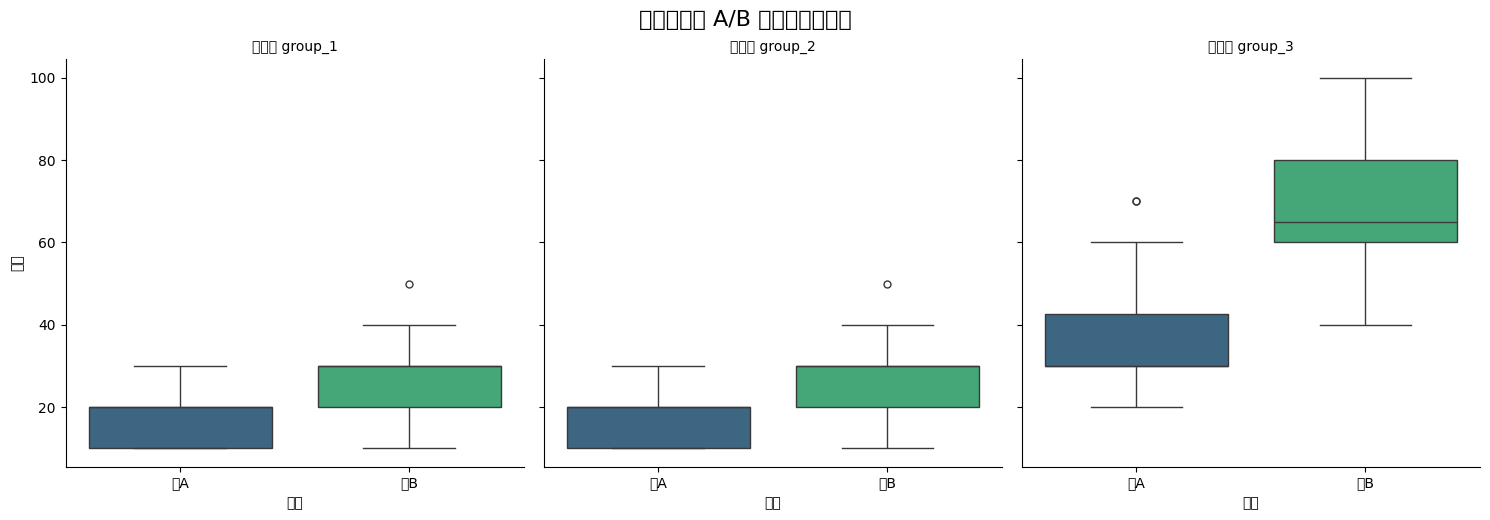

In [59]:
g = sns.catplot(
    data=df_long,      # 使用我们准备好的长格式数据
    x='分组',          # 每个子图的X轴是'组A'和'组B'
    y='数值',          # Y轴是具体的数值
    col='实验组',        # 关键参数：根据'实验组'的编号来创建子图（列）
    kind='box',        # 指定图的类型为箱线图 (box plot)
    palette='viridis'  # 使用一个好看的调色板
)

g.fig.suptitle('各实验组内 A/B 组数据分布对比', y=1.03, fontsize=16) # 设置总标题
g.set_axis_labels("分组", "数值") # 设置x, y轴的统一标签
g.set_titles("实验组 {col_name}") # 设置每个子图的标题

In [58]:
plt.show()